In [28]:
# ─── Step 1: Import Required Libraries ───────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import pandas as pd
from scipy.spatial.distance import euclidean, cityblock, minkowski

In [29]:
# ─── Step 2: Load Dataset ─────────────────────────────────────────────────────
# Load the Iris dataset from sklearn (built-in dataset)
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [30]:
# ─── Step 3: Subset Selection ─────────────────────────────────────────────────
# Select a SUBSET of features: 'sepal length (cm)' and 'petal length (cm)'
# Select a SUBSET of samples: first 5 rows (indices 0 to 4)

feature_subset = ['sepal length (cm)', 'petal length (cm)']
sample_subset = df[feature_subset].iloc[:5]

print("Selected Features:", feature_subset)
print("\nSample Subset:\n", sample_subset)

Selected Features: ['sepal length (cm)', 'petal length (cm)']

Sample Subset:
    sepal length (cm)  petal length (cm)
0                5.1                1.4
1                4.9                1.4
2                4.7                1.3
3                4.6                1.5
4                5.0                1.4


In [31]:
# ─── Step 5: Compute Pairwise Distances for All Sample Pairs ──────────────────
# We compare every unique pair from the 5 selected samples

samples = sample_subset.values  # Convert to numpy array for computation

print("\nPairwise Distances:\n")

for i in range(len(samples)):
    for j in range(i + 1, len(samples)):

        euc = euclidean(samples[i], samples[j])
        man = cityblock(samples[i], samples[j])
        mink = minkowski(samples[i], samples[j], p=3)

        print(f"P{i}-P{j}: Euclidean={euc:.3f}, Manhattan={man:.3f}, Minkowski={mink:.3f}")


Pairwise Distances:

P0-P1: Euclidean=0.200, Manhattan=0.200, Minkowski=0.200
P0-P2: Euclidean=0.412, Manhattan=0.500, Minkowski=0.402
P0-P3: Euclidean=0.510, Manhattan=0.600, Minkowski=0.501
P0-P4: Euclidean=0.100, Manhattan=0.100, Minkowski=0.100
P1-P2: Euclidean=0.224, Manhattan=0.300, Minkowski=0.208
P1-P3: Euclidean=0.316, Manhattan=0.400, Minkowski=0.304
P1-P4: Euclidean=0.100, Manhattan=0.100, Minkowski=0.100
P2-P3: Euclidean=0.224, Manhattan=0.300, Minkowski=0.208
P2-P4: Euclidean=0.316, Manhattan=0.400, Minkowski=0.304
P3-P4: Euclidean=0.412, Manhattan=0.500, Minkowski=0.402


In [32]:
# Step: Effect of p on Minkowski Distance (between P0 and P4)

p1 = samples[0]
p2 = samples[4]

print("\nEffect of p on Minkowski Distance:\n")

for p in range(1, 6):   # keep small range (1 to 5)
    dist = minkowski(p1, p2, p=p)

    if p == 1:
        print(f"p={p}: {dist:.3f} (Manhattan)")
    elif p == 2:
        print(f"p={p}: {dist:.3f} (Euclidean)")
    else:
        print(f"p={p}: {dist:.3f}")


Effect of p on Minkowski Distance:

p=1: 0.100 (Manhattan)
p=2: 0.100 (Euclidean)
p=3: 0.100
p=4: 0.100
p=5: 0.100


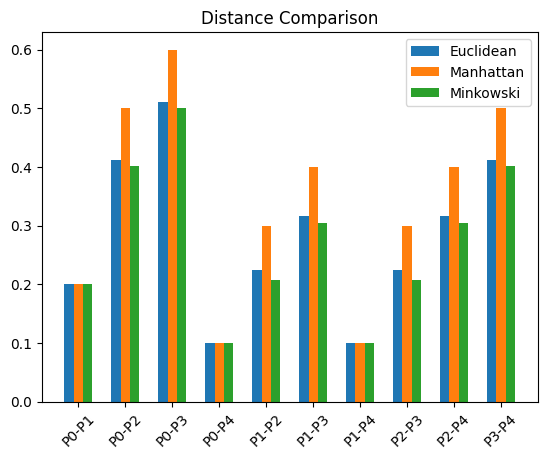

In [35]:
# Simple bar chart (correct comparison)

import matplotlib.pyplot as plt
import numpy as np

pairs = []
euc = []
man = []
mink = []

# Compute distances
for i in range(len(samples)):
    for j in range(i+1, len(samples)):
        pairs.append(f"P{i}-P{j}")
        euc.append(euclidean(samples[i], samples[j]))
        man.append(cityblock(samples[i], samples[j]))
        mink.append(minkowski(samples[i], samples[j], p=3))

x = np.arange(len(pairs))

# Plot (simple side-by-side)
plt.bar(x-0.2, euc, width=0.2, label='Euclidean')
plt.bar(x,     man, width=0.2, label='Manhattan')
plt.bar(x+0.2, mink, width=0.2, label='Minkowski')

plt.xticks(x, pairs, rotation=45)
plt.title("Distance Comparison")
plt.legend()

plt.show()

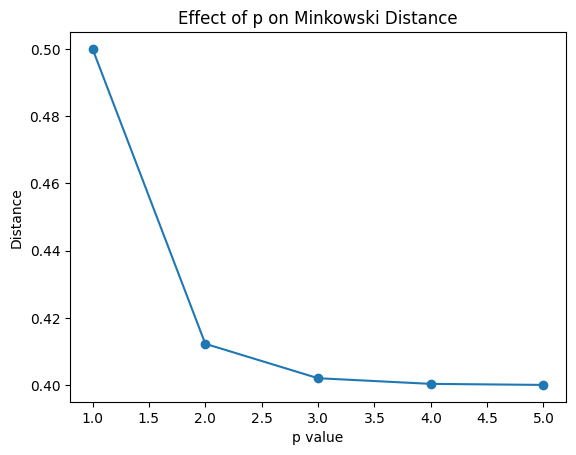

In [36]:
# Plot 2: Effect of p on Minkowski distance

import matplotlib.pyplot as plt

p_vals = range(1, 6)   # keep small for exam
mink_vals = []

for p in p_vals:
    mink_vals.append(minkowski(samples[0], samples[2], p=p))

plt.plot(p_vals, mink_vals, marker='o')

plt.title("Effect of p on Minkowski Distance")
plt.xlabel("p value")
plt.ylabel("Distance")

plt.show()